# Deliverable 6: Single-Cell RNA-Seq Analysis

This notebook prepares the environment and data for a simplified scRNA-seq pipeline following Single-cell Best Practices. It will:
- Build a cell-gene expression matrix (AnnData)
- Cluster cells with Leiden
- Annotate cell types with CellTypist

## System Requirements Check

This section checks system and Python dependencies:
- System: `cmake`, `libtbb12`, `wget`, `curl`
- Python: `scanpy`, `anndata<0.11`, `leidenalg`, `celltypist`

Notes:
- No automatic `sudo apt-get` will be executed. Missing system packages will show a suggested command for you to run manually in a terminal.
- Python packages missing will be installed with `pip --user`.


In [ ]:
%%bash
set -u
export PATH="$HOME/.local/bin:$HOME/.cargo/bin:$PATH"

printf "\n=== System & Python Environment Check ===\n"

# --- System package checks (cmake, libtbb12, wget, curl) ---
missing_pkgs=()

check_cmd() {
  if command -v "$1" >/dev/null 2>&1; then
    printf "[OK] %s is installed at %s\n" "$1" "$(command -v "$1")"
  else
    printf "[MISSING] %s is not installed\n" "$1"
    missing_pkgs+=("$2")
  fi
}

# cmake, wget, curl are commands; libtbb12 is a Debian package
check_cmd cmake cmake
check_cmd wget wget
check_cmd curl curl

# Check libtbb12 via dpkg; fall back to checking shared object presence
if dpkg -s libtbb12 >/dev/null 2>&1; then
  echo "[OK] libtbb12 package is installed (dpkg)"
else
  if ls /usr/lib/*/libtbb.so.12 >/dev/null 2>&1; then
    echo "[OK] libtbb12 library found"
  else
    echo "[MISSING] libtbb12 (Intel TBB runtime)"
    missing_pkgs+=("libtbb12")
  fi
fi

if [ ${#missing_pkgs[@]} -gt 0 ]; then
  echo "\nMissing system packages detected: ${missing_pkgs[*]}"
  echo "Suggested install (requires sudo):"
  echo "  sudo apt-get update && sudo apt-get install -y ${missing_pkgs[*]}"
  echo "Note: This notebook will not run sudo automatically. Please run the command above in your terminal."
else
  echo "All required system packages are present."
fi

# --- Python package checks and installs (user-level) ---
python3 - <<'PY'
import sys, subprocess

print("\n--- Python packages ---")

def ensure(pkg, install_name=None, constraint=None):
    name = install_name or pkg
    spec = name if constraint is None else f"{name}{constraint}"
    try:
        mod = __import__(pkg)
        if pkg == 'anndata':
            ver = getattr(mod, '__version__', '0')
            def parse(v):
                parts = []
                for p in v.split('.'):
                    num = ''
                    for ch in p:
                        if ch.isdigit(): num += ch
                        else: break
                    parts.append(int(num or '0'))
                return tuple(parts + [0]*(3-len(parts)))
            if parse(ver) >= (0,11,0):
                print(f"[UPGRADE/DOWNGRADE] anndata {ver} -> enforcing <0.11")
                subprocess.run([sys.executable, '-m', 'pip', 'install', '--user', 'anndata<0.11'], check=False)
            else:
                print(f"[OK] anndata {ver}")
        else:
            print(f"[OK] {pkg} present")
    except Exception:
        print(f"[INSTALL] {spec}")
        subprocess.run([sys.executable, '-m', 'pip', 'install', '--user', spec], check=False)

ensure('scanpy')
ensure('anndata', 'anndata', '<0.11')
ensure('leidenalg')
ensure('celltypist')

# Show pip location/version for clarity
subprocess.run([sys.executable, '-m', 'pip', '--version'])
PY

printf "\nEnvironment check complete. If system packages were missing, copy the suggested sudo apt-get command to your terminal and re-run this cell.\n"


## Data Download & Setup


In [ ]:
%%bash
set -u
export PATH="$HOME/.local/bin:$HOME/.cargo/bin:$PATH"

DATA_DIR="data"
BOX_URL="https://app.box.com/s/lx2xownlrhz3us8496tyu9c4dgade814"
TARBALL="toy_read_ref_set.tar.gz"
WL_GZ_URL="https://github.com/f0t1h/3M-february-2018/raw/refs/heads/master/3M-february-2018.txt.gz"
WL_GZ_PATH="$DATA_DIR/3M-february-2018.txt.gz"
WL_TXT_PATH="$DATA_DIR/3M-february-2018.txt"

mkdir -p "$DATA_DIR"

printf "\n=== Data Setup ===\n"

# 1) Always ensure whitelist first so subsequent messages aren't buried by progress
if [ -f "$WL_TXT_PATH" ]; then
  printf "Whitelist present: %s\n" "$WL_TXT_PATH"
else
  printf "Fetching 10x v3 whitelist ...\n"
  wget -q --show-progress -O "$WL_GZ_PATH" "$WL_GZ_URL" || { echo "Failed to download whitelist"; exit 1; }
  gunzip -f "$WL_GZ_PATH" || { echo "Failed to extract whitelist"; exit 1; }
  if [ -f "$WL_TXT_PATH" ]; then
    printf "Whitelist ready: %s\n" "$WL_TXT_PATH"
  else
    echo "Whitelist missing after extraction."; exit 1;
  fi
fi

# 2) Handle sample data presence / extraction
DATA_READY=0
# Canonical layout
if [ -d "$DATA_DIR/toy_ref_read/toy_read_fastq" ] && [ -d "$DATA_DIR/toy_ref_read/toy_human_ref" ]; then
  DATA_READY=1
fi

# If not canonical, normalize if top-level dirs exist
if [ "$DATA_READY" -eq 0 ] && [ -d "$DATA_DIR/toy_read_fastq" ] && [ -d "$DATA_DIR/toy_human_ref" ]; then
  printf "Found existing data at %s; normalizing layout to %s/toy_ref_read...\n" "$DATA_DIR" "$DATA_DIR"
  mkdir -p "$DATA_DIR/toy_ref_read"
  [ -d "$DATA_DIR/toy_ref_read/toy_read_fastq" ] || mv "$DATA_DIR/toy_read_fastq" "$DATA_DIR/toy_ref_read/" 2>/dev/null || true
  [ -d "$DATA_DIR/toy_ref_read/toy_human_ref" ] || mv "$DATA_DIR/toy_human_ref" "$DATA_DIR/toy_ref_read/" 2>/dev/null || true
  if [ -d "$DATA_DIR/toy_ref_read/toy_read_fastq" ] && [ -d "$DATA_DIR/toy_ref_read/toy_human_ref" ]; then
    DATA_READY=1
  fi
fi

# If still not ready, try to extract from tarball if present
if [ "$DATA_READY" -eq 0 ] && [ -f "$TARBALL" ]; then
  printf "Found %s. Extracting into %s/...\n" "$TARBALL" "$DATA_DIR"
  tar -xzf "$TARBALL" -C "$DATA_DIR" || { echo "Extraction failed"; exit 1; }
  # Normalize if tar created a top folder
  if [ -d "$DATA_DIR/toy_read_ref_set" ]; then
    [ -d "$DATA_DIR/toy_ref_read/toy_read_fastq" ] || mv "$DATA_DIR/toy_read_ref_set/toy_read_fastq" "$DATA_DIR/" 2>/dev/null || true
    [ -d "$DATA_DIR/toy_ref_read/toy_human_ref" ] || mv "$DATA_DIR/toy_read_ref_set/toy_human_ref" "$DATA_DIR/" 2>/dev/null || true
    rmdir "$DATA_DIR/toy_read_ref_set" 2>/dev/null || true
  fi
  # Ensure canonical layout under toy_ref_read
  mkdir -p "$DATA_DIR/toy_ref_read"
  [ -d "$DATA_DIR/toy_ref_read/toy_read_fastq" ] || mv "$DATA_DIR/toy_read_fastq" "$DATA_DIR/toy_ref_read/" 2>/dev/null || true
  [ -d "$DATA_DIR/toy_ref_read/toy_human_ref" ] || mv "$DATA_DIR/toy_human_ref" "$DATA_DIR/toy_ref_read/" 2>/dev/null || true

  if [ -d "$DATA_DIR/toy_ref_read/toy_read_fastq" ] && [ -d "$DATA_DIR/toy_ref_read/toy_human_ref" ]; then
    DATA_READY=1
    printf "OK: toy_ref_read directory prepared.\n"
    # Remove tarball after successful extraction to keep workspace clean
    rm -f "$TARBALL" && printf "Removed archive: %s\n" "$TARBALL" || true
  else
    echo "Warning: Expected folders not found after extraction. Contents of $DATA_DIR:"; ls -la "$DATA_DIR"
  fi
fi

# If data still missing, show Box instructions now (after whitelist progress) and exit gracefully
if [ "$DATA_READY" -eq 0 ]; then
  printf "[Action Required]\n"
  printf "Box requires a browser for download.\n"
  printf "1) Open: %s\n" "$BOX_URL"
  printf "2) Download file: %s\n" "$TARBALL"
  printf "3) Place it next to this notebook: %s/%s\n" "$(pwd)" "$TARBALL"
  printf "4) Re-run this cell.\n"
  exit 0
fi

# 3) Summary (only when data available)
printf "\nData directory summary:\n"
du -h --max-depth=2 "$DATA_DIR" 2>/dev/null || true

# List key files if present
if [ -d "$DATA_DIR/toy_ref_read/toy_human_ref/fasta" ]; then
  echo "Reference FASTA(s):"; ls -lh "$DATA_DIR/toy_ref_read/toy_human_ref/fasta" || true
fi
if [ -d "$DATA_DIR/toy_ref_read/toy_human_ref/genes" ]; then
  echo "GTF(s):"; ls -lh "$DATA_DIR/toy_ref_read/toy_human_ref/genes" || true
fi
if [ -d "$DATA_DIR/toy_ref_read/toy_read_fastq" ]; then
  echo "FASTQs:"; ls -lh "$DATA_DIR/toy_ref_read/toy_read_fastq" | head -n 20 || true
fi

## Tool Installation


In [ ]:
%%bash
# Installer for salmon, cargo, alevin-fry, simpleaf with fallbacks for simpleaf
set -u
export PATH="$HOME/.local/bin:$HOME/.cargo/bin:$PATH"
export CARGO_TERM_COLOR=always

# Set ALEVIN_FRY_HOME for simpleaf (required environment variable)
export ALEVIN_FRY_HOME="$HOME/.alevin_fry"
mkdir -p "$ALEVIN_FRY_HOME"

# Persist to .bashrc if not already present
if ! grep -q "ALEVIN_FRY_HOME" "$HOME/.bashrc" 2>/dev/null; then
  echo "export ALEVIN_FRY_HOME=\"$HOME/.alevin_fry\"" >> "$HOME/.bashrc"
fi

printf "\n=== Pipeline Tool Check/Install ===\n"
SALMON_VERSION="1.10.0"
SALMON_TARBALL="salmon-${SALMON_VERSION}_linux_x86_64.tar.gz"
SALMON_URL="https://github.com/COMBINE-lab/salmon/releases/download/v${SALMON_VERSION}/${SALMON_TARBALL}"
INSTALL_BIN="$HOME/.local/bin"
mkdir -p "$INSTALL_BIN"

status() { printf "[tool] %s\n" "$1"; }
err() { printf "[error] %s\n" "$1" >&2; }

# Pre-check for git (cargo may need it)
if ! command -v git >/dev/null 2>&1; then
  err "git not found. Install it in a terminal: sudo apt-get install -y git"
fi

# 1. cargo / Rust toolchain
if ! command -v cargo >/dev/null 2>&1; then
  status "cargo missing -> installing Rust toolchain"
  if curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh -s -- -y; then
    . "$HOME/.cargo/env" && status "cargo installed: $(command -v cargo)"
  else
    err "Rust installation failed. Manual: curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh -s -- -y"
  fi
else
  status "cargo present: $(command -v cargo)"
fi
export PATH="$HOME/.local/bin:$HOME/.cargo/bin:$PATH"

# Keep toolchain current (no sudo)
if command -v rustup >/dev/null 2>&1; then
  rustup update >/dev/null 2>&1 || true
  rustup default stable >/dev/null 2>&1 || true
fi
status "rustc: $(rustc --version 2>/dev/null || echo 'not found')"

# 2. salmon
if command -v salmon >/dev/null 2>&1; then
  status "salmon present: $(salmon --version | head -n1)"
else
  status "salmon missing -> downloading ${SALMON_TARBALL}"
  rm -f "$SALMON_TARBALL"
  if wget -q --show-progress "$SALMON_URL"; then
    if tar -xzf "$SALMON_TARBALL"; then
      if [ -f "salmon-${SALMON_VERSION}_linux_x86_64/bin/salmon" ]; then
        mv "salmon-${SALMON_VERSION}_linux_x86_64/bin/salmon" "$INSTALL_BIN/" && chmod +x "$INSTALL_BIN/salmon" && status "salmon installed"
        rm -rf "salmon-${SALMON_VERSION}_linux_x86_64" "$SALMON_TARBALL"
        status "salmon version: $(salmon --version | head -n1)"
      else
        err "Expected salmon binary not found after extraction"
      fi
    else
      err "Failed to extract $SALMON_TARBALL"
    fi
  else
    err "Download failed: $SALMON_URL"
  fi
fi

# 3. alevin-fry
if command -v alevin-fry >/dev/null 2>&1; then
  status "alevin-fry present: $(alevin-fry --version 2>&1 | head -n1)"
else
  status "alevin-fry missing -> cargo install --locked alevin-fry"
  if cargo install --locked alevin-fry; then
    status "alevin-fry installed: $(alevin-fry --version 2>&1 | head -n1)"
  else
    err "alevin-fry install failed. Install prerequisites (terminal): sudo apt-get install -y build-essential cmake pkg-config libssl-dev zlib1g-dev libcurl4-openssl-dev"
  fi
fi

# 4. simpleaf with version fallbacks (jrsonnet API break workaround)
install_simpleaf() {
  # Try latest first
  if cargo install --locked simpleaf; then
    return 0
  fi
  # Known working fallbacks (adjusted for jrsonnet changes)
  for v in 0.18.3 0.18.2 0.18.1 0.17.3; do
    status "retrying: cargo install --locked simpleaf --version ${v}"
    if cargo install --locked simpleaf --version "${v}"; then
      return 0
    fi
  done
  return 1
}

if command -v simpleaf >/dev/null 2>&1; then
  status "simpleaf present: $(simpleaf --version 2>&1 | head -n1)"
else
  status "simpleaf missing -> attempting cargo install with fallbacks"
  if install_simpleaf; then
    status "simpleaf installed: $(simpleaf --version 2>&1 | head -n1)"
  else
    err "simpleaf install failed across versions. Likely due to jrsonnet API mismatch."
    err "Options:"
    err "  1) Install build deps (terminal) then retry: sudo apt-get update && sudo apt-get install -y build-essential cmake pkg-config libssl-dev zlib1g-dev libcurl4-openssl-dev git"
    err "  2) Use alevin-fry directly (without simpleaf). I can add those cells next."
  fi
fi

# Summary
printf "\n=== Tool Summary ===\n"
for t in salmon alevin-fry simpleaf cargo; do
  if command -v "$t" >/dev/null 2>&1; then
    printf "%-12s -> %s\n" "$t" "$(command -v "$t")"
  else
    printf "%-12s -> NOT FOUND\n" "$t"
  fi
done


## Reference Indexing

In [21]:
%%bash
set -u
export PATH="$HOME/.local/bin:$HOME/.cargo/bin:$PATH"
export ALEVIN_FRY_HOME="$HOME/.alevin_fry"

DATA_DIR="data/toy_ref_read"
REF_DIR="$DATA_DIR/toy_human_ref"
GENOME_FA="$REF_DIR/fasta/genome.fa"
GENES_GTF="$REF_DIR/genes/genes.gtf"
INDEX_DIR="data/simpleaf_index"

printf "\n=== Reference Indexing ===\n"

# Check for required files
if [ ! -f "$GENOME_FA" ]; then
  echo "Error: Reference genome not found at $GENOME_FA"
  exit 1
fi
if [ ! -f "$GENES_GTF" ]; then
  echo "Error: GTF file not found at $GENES_GTF"
  exit 1
fi

# Skip if index already exists
if [ -d "$INDEX_DIR" ] && [ -f "$INDEX_DIR/index/complete_ref_lens.bin" ]; then
  printf "Index already exists at %s\n" "$INDEX_DIR"
  printf "Index metadata:\n"
  ls -lh "$INDEX_DIR/index/" | head -n 10
  exit 0
fi

# Set paths for simpleaf
printf "Configuring simpleaf paths...\n"
simpleaf set-paths

# Build index (read length 90 for this toy dataset)
printf "\nBuilding salmon index (this may take a few minutes)...\n"
simpleaf index \
  --output "$INDEX_DIR" \
  --fasta "$GENOME_FA" \
  --gtf "$GENES_GTF" \
  --rlen 90 \
  --threads 8 \
  --no-piscem

# Verify and show results
if [ -d "$INDEX_DIR" ] && [ -f "$INDEX_DIR/index/complete_ref_lens.bin" ]; then
  printf "\n=== Index Complete ===\n"
  printf "Index location: %s\n" "$INDEX_DIR"
  printf "Index size: %s\n" "$(du -sh "$INDEX_DIR" | cut -f1)"
  printf "\nIndex contents:\n"
  ls -lh "$INDEX_DIR/index/" | head -n 10
else
  echo "Error: Index build appears to have failed"
  exit 1
fi


=== Reference Indexing ===
Configuring simpleaf paths...
Configuring simpleaf paths...
2025-11-18T08:23:47.815248Z  INFO simpleaf::utils::prog_utils: could not find piscem executable, so salmon will be required.
found `salmon` in the PATH at /home/ryan/.local/bin/salmon
found `alevin-fry` in the PATH at /home/ryan/.cargo/bin/alevin-fry
2025-11-18T08:23:47.815248Z  INFO simpleaf::utils::prog_utils: could not find piscem executable, so salmon will be required.
found `salmon` in the PATH at /home/ryan/.local/bin/salmon
found `alevin-fry` in the PATH at /home/ryan/.cargo/bin/alevin-fry

Building salmon index (this may take a few minutes)...
2025-11-18T08:23:47.845351Z  INFO simpleaf::simpleaf_commands::indexing: preparing to make reference with roers
2025-11-18T08:23:47.850119Z  INFO grangers::reader::gtf: Finished parsing the input file. Found 3 comments and 2439 records.

Building salmon index (this may take a few minutes)...
2025-11-18T08:23:47.845351Z  INFO simpleaf::simpleaf_commands

## Quantification

In [22]:
%%bash
set -u
export PATH="$HOME/.local/bin:$HOME/.cargo/bin:$PATH"
export ALEVIN_FRY_HOME="$HOME/.alevin_fry"

DATA_DIR="data/toy_ref_read"
FASTQ_DIR="$DATA_DIR/toy_read_fastq"
INDEX_DIR="data/simpleaf_index"
QUANT_DIR="data/simpleaf_quant"
WHITELIST="data/3M-february-2018.txt"

printf "\n=== Quantification ===\n"

# Check prerequisites
if [ ! -d "$INDEX_DIR" ]; then
  echo "Error: Index not found at $INDEX_DIR. Run indexing cell first."
  exit 1
fi
if [ ! -f "$WHITELIST" ]; then
  echo "Error: Whitelist not found at $WHITELIST"
  exit 1
fi
if [ ! -d "$FASTQ_DIR" ]; then
  echo "Error: FASTQ directory not found at $FASTQ_DIR"
  exit 1
fi

# Skip if quantification already complete
if [ -d "$QUANT_DIR/af_quant/alevin" ] && [ -f "$QUANT_DIR/af_quant/alevin/quants_mat.mtx" ]; then
  printf "Quantification already complete at %s\n" "$QUANT_DIR"
  printf "\nMatrix Market header (rows x cols):\n"
  head -n 3 "$QUANT_DIR/af_quant/alevin/quants_mat.mtx"
  printf "\nCounts by file:\n"
  printf "  Barcodes (rows/cells): %s\n" "$(wc -l < "$QUANT_DIR/af_quant/alevin/quants_mat_rows.txt")"
  printf "  Features (cols/genes): %s\n" "$(wc -l < "$QUANT_DIR/af_quant/alevin/quants_mat_cols.txt")"
  exit 0
fi

# Collect all FASTQ files (R1 = barcode+UMI, R2 = cDNA), comma-separated and sorted
printf "Discovering FASTQ files...\n"
reads1=$(find -L "$FASTQ_DIR" -type f -name "*_R1_*.fastq*" | sort | paste -sd, -)
reads2=$(find -L "$FASTQ_DIR" -type f -name "*_R2_*.fastq*" | sort | paste -sd, -)

if [ -z "$reads1" ] || [ -z "$reads2" ]; then
  echo "Error: Could not find paired R1/R2 FASTQ files in $FASTQ_DIR"
  ls -lh "$FASTQ_DIR"
  exit 1
fi

printf "R1 (barcode) files: %s\n" "$reads1"
printf "R2 (cDNA) files:   %s\n" "$reads2"

# Run quantification in USA mode (spliced/unspliced/ambiguous) with cr-like UMI resolution
# Requires t2g_3col.tsv produced during indexing
T2G="$INDEX_DIR/index/t2g_3col.tsv"
if [ ! -f "$T2G" ]; then
  echo "Error: t2g_3col.tsv not found at $T2G (re-run indexing cell)."
  exit 1
fi

printf "\nRunning simpleaf quant (this may take several minutes)...\n"
simpleaf quant \
  -c 10xv3 -t 8 \
  -1 "$reads1" -2 "$reads2" \
  -i "$INDEX_DIR/index" \
  -u -r cr-like \
  -m "$T2G" \
  -o "$QUANT_DIR"

# Verify and show results
if [ -f "$QUANT_DIR/af_quant/alevin/quants_mat.mtx" ]; then
  printf "\n=== Quantification Complete ===\n"
  printf "Output directory: %s\n" "$QUANT_DIR/af_quant/alevin"
  printf "Total size: %s\n" "$(du -sh "$QUANT_DIR" | cut -f1)"
  
  printf "\nMatrix Market header (rows x cols):\n"
  head -n 3 "$QUANT_DIR/af_quant/alevin/quants_mat.mtx"
  
  printf "\nCounts by file (per alevin-fry spec):\n"
  printf "  Barcodes (rows/cells): %s\n" "$(wc -l < "$QUANT_DIR/af_quant/alevin/quants_mat_rows.txt")"
  printf "  Features (cols/genes or gene-variants): %s\n" "$(wc -l < "$QUANT_DIR/af_quant/alevin/quants_mat_cols.txt")"
  
  printf "\nSample barcodes (first 5):\n"
  head -n 5 "$QUANT_DIR/af_quant/alevin/quants_mat_rows.txt"
  
  printf "\nSample features (first 5):\n"
  head -n 5 "$QUANT_DIR/af_quant/alevin/quants_mat_cols.txt"
else
  echo "Error: Quantification appears to have failed"
  exit 1
fi


=== Quantification ===
Discovering FASTQ files...
R1 (barcode) files: data/toy_ref_read/toy_read_fastq/selected_R1_reads.fastq
R2 (cDNA) files:   data/toy_ref_read/toy_read_fastq/selected_R2_reads.fastq

Running simpleaf quant (this may take several minutes)...
Discovering FASTQ files...
R1 (barcode) files: data/toy_ref_read/toy_read_fastq/selected_R1_reads.fastq
R2 (cDNA) files:   data/toy_ref_read/toy_read_fastq/selected_R2_reads.fastq

Running simpleaf quant (this may take several minutes)...
2025-11-18T08:23:56.238479Z  INFO simpleaf::utils::af_utils: The directory /home/ryan/.alevin_fry/plist doesn't yet exist; attempting to create it.
2025-11-18T08:23:56.238586Z  INFO simpleaf::utils::af_utils: Expected /home/ryan/.alevin_fry/plist/2c9dfb98babe5a57ae763778adb9ebb7bfa531e105823bc26163892089333f8c but didn't find it, will try to download it using a remote url.
2025-11-18T08:23:56.238479Z  INFO simpleaf::utils::af_utils: The directory /home/ryan/.alevin_fry/plist doesn't yet exist;

## Data Loading

In [24]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import mmread
import scipy.sparse as sp

# Configure scanpy
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white')

# Load alevin-fry output robustly
print("Loading quantification data...")
mtx_path = 'data/simpleaf_quant/af_quant/alevin/quants_mat.mtx'
rows_path = 'data/simpleaf_quant/af_quant/alevin/quants_mat_rows.txt'
cols_path = 'data/simpleaf_quant/af_quant/alevin/quants_mat_cols.txt'

X = mmread(mtx_path).tocsr()
rows = pd.read_csv(rows_path, header=None)[0].astype(str).values
cols = pd.read_csv(cols_path, header=None)[0].astype(str).values

# Ensure orientation matches files: rows -> barcodes (cells), cols -> features (genes or USA variants)
if X.shape != (len(rows), len(cols)):
    X = X.T

adata = sc.AnnData(X)
adata.obs_names = rows
adata.var_names = cols

print(f"Matrix shape (cells x features): {adata.shape}")
print(f"Barcodes file has {len(rows)} entries (cells)")
print(f"Features file has {len(cols)} entries (genes or USA variants)")

# If USA features detected (suffix -S/-U/-A), collapse to gene-level counts
def collapse_usa(adata):
    idx = adata.var_names
    # Coerce all feature names to pure Python strings
    try:
        names = idx.astype(str).values
    except Exception:
        names = np.array([str(x) for x in idx])

    bases = []
    usa_found = False
    for nm in names:
        # Safe handling even if nm is not a string-like
        s = str(nm)
        if '-' in s:
            base, suf = s.rsplit('-', 1)
            if suf in ('S', 'U', 'A'):
                bases.append(base)
                usa_found = True
            else:
                bases.append(s)
        else:
            bases.append(s)

    if not usa_found:
        return adata  # nothing to collapse

    bases = np.array(bases, dtype=object)
    uniq, inv = np.unique(bases, return_inverse=True)

    # Build a sparse indicator to sum USA variants into one column per gene id
    n_feat = len(inv)
    n_gene = len(uniq)
    row_ix = np.arange(n_feat)
    col_ix = inv
    data = np.ones(n_feat, dtype=np.int8)
    M = sp.csr_matrix((data, (row_ix, col_ix)), shape=(n_feat, n_gene))

    Xc = adata.X @ M  # (cells x features) @ (features x genes) -> (cells x genes)
    adata_out = sc.AnnData(Xc, obs=adata.obs.copy())
    adata_out.var_names = uniq
    return adata_out

adata = collapse_usa(adata)

print(f"\nLoaded AnnData (post-USA collapse if applicable): {adata.n_obs} cells x {adata.n_vars} genes")
print(f"  Total counts: {adata.X.sum():,.0f}")
try:
    mean_counts = float(np.asarray(adata.X.sum(axis=1)).ravel().mean()) if sp.issparse(adata.X) else float(adata.X.sum(axis=1).mean())
    print(f"  Mean counts per cell: {mean_counts:.1f}")
except Exception:
    pass

Loading quantification data...
Matrix shape (cells x features): (139, 60)
Barcodes file has 139 entries (cells)
Features file has 60 entries (genes or USA variants)

Loaded AnnData (post-USA collapse if applicable): 139 cells x 20 genes
  Total counts: 8,911
  Mean counts per cell: 64.1


## QC and Filtering

In [30]:
# Calculate QC metrics
# Toy dataset is extremely sparse; avoid percent_top and add fallback
sc.pp.calculate_qc_metrics(adata, percent_top=[], inplace=True)

print("QC metrics calculated:")
print(f"  Mean genes per cell: {adata.obs['n_genes_by_counts'].mean():.0f}")
print(f"  Mean counts per cell: {adata.obs['total_counts'].mean():.0f}")

# Filter cells: toy dataset has very low counts, use lenient thresholds
# Keep cells with at least 10 genes detected (instead of standard 200)
print("\nFiltering cells (min 10 genes)...")
sc.pp.filter_cells(adata, min_genes=10)

# Filter genes: present in at least 1 cell (very lenient for toy data)
print("Filtering genes (min 1 cell)...")
sc.pp.filter_genes(adata, min_cells=1)

print(f"\nFiltered AnnData: {adata.n_obs} cells x {adata.n_vars} genes")

QC metrics calculated:
  Mean genes per cell: 15
  Mean counts per cell: 79

Filtering cells (min 10 genes)...
Filtering genes (min 1 cell)...

Filtered AnnData: 109 cells x 19 genes


## Normalization and Preprocessing

In [32]:
# Normalize to 10,000 counts per cell
import numpy as np
print("Normalizing to 10,000 counts per cell...")
sc.pp.normalize_total(adata, target_sum=1e4)

# Log transform
print("Log-transforming...")
sc.pp.log1p(adata)

# Identify highly variable genes (adapt to tiny gene set)
print("Identifying highly variable genes...")
n_top = int(min(2000, adata.n_vars))
sc.pp.highly_variable_genes(adata, n_top_genes=n_top)
num_hvgs = int(adata.var['highly_variable'].sum())
print(f"  Found {num_hvgs} highly variable genes (requested up to {n_top})")

# Store raw data and subset to HVGs; if none flagged, keep all genes
adata.raw = adata
hvg_mask = adata.var['highly_variable'].values if 'highly_variable' in adata.var else None
if hvg_mask is None or num_hvgs == 0:
    print("  No HVGs flagged; proceeding with all genes.")
    hvg_mask = np.ones(adata.n_vars, dtype=bool)
adata = adata[:, hvg_mask]

print(f"\nPreprocessed: {adata.n_obs} cells x {adata.n_vars} HVGs")

Normalizing to 10,000 counts per cell...
normalizing counts per cell
    finished (0:00:00)
Log-transforming...
Identifying highly variable genes...
extracting highly variable genes
    finished (0:00:00)
Log-transforming...
Identifying highly variable genes...
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
  Found 19 highly variable genes (requested up to 19)

Preprocessed: 109 cells x 19 HVGs
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
  Found 19 highly variable genes (requested up to 19)

Preprocessed: 109 cells x 19 HVGs


/home/ryan/.local/lib/python3.13/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


## Dimensionality Reduction and Clustering

In [44]:
# Scale data
print("Scaling data...")
sc.pp.scale(adata, max_value=10)

# PCA with adaptive number of components
n_comps = int(min(40, max(2, adata.n_vars - 1)))
print(f"Computing PCA ({n_comps} components)...")
sc.tl.pca(adata, n_comps=n_comps)

# Compute neighbors graph with adaptive PCs and k
k = int(min(10, max(2, adata.n_obs - 1)))
print(f"Computing neighbors graph (k={k}, n_pcs={n_comps})...")
sc.pp.neighbors(adata, n_neighbors=k, n_pcs=n_comps)

# UMAP embedding
print("Computing UMAP embedding...")
sc.tl.umap(adata)

# Leiden clustering via igraph backend (future Scanpy default)
print("Running Leiden clustering (igraph backend, resolution=0.5)...")
sc.tl.leiden(adata, resolution=0.5, flavor="igraph", n_iterations=2, directed=False, random_state=0)

print(f"\nClustering complete: {adata.obs['leiden'].nunique()} clusters identified")

Scaling data...
Computing PCA (18 components)...
computing PCA
    with n_comps=18
    finished (0:00:00)
Computing neighbors graph (k=10, n_pcs=18)...
computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
    with n_comps=18
    finished (0:00:00)
Computing neighbors graph (k=10, n_pcs=18)...
computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
Computing UMAP embedding...
computing UMAP
Computing UMAP embedding...
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:00)
Running Leiden clustering (igraph backend, resolution=0.5)...
running Leiden clustering
    finished: found

## Clustering Visualization

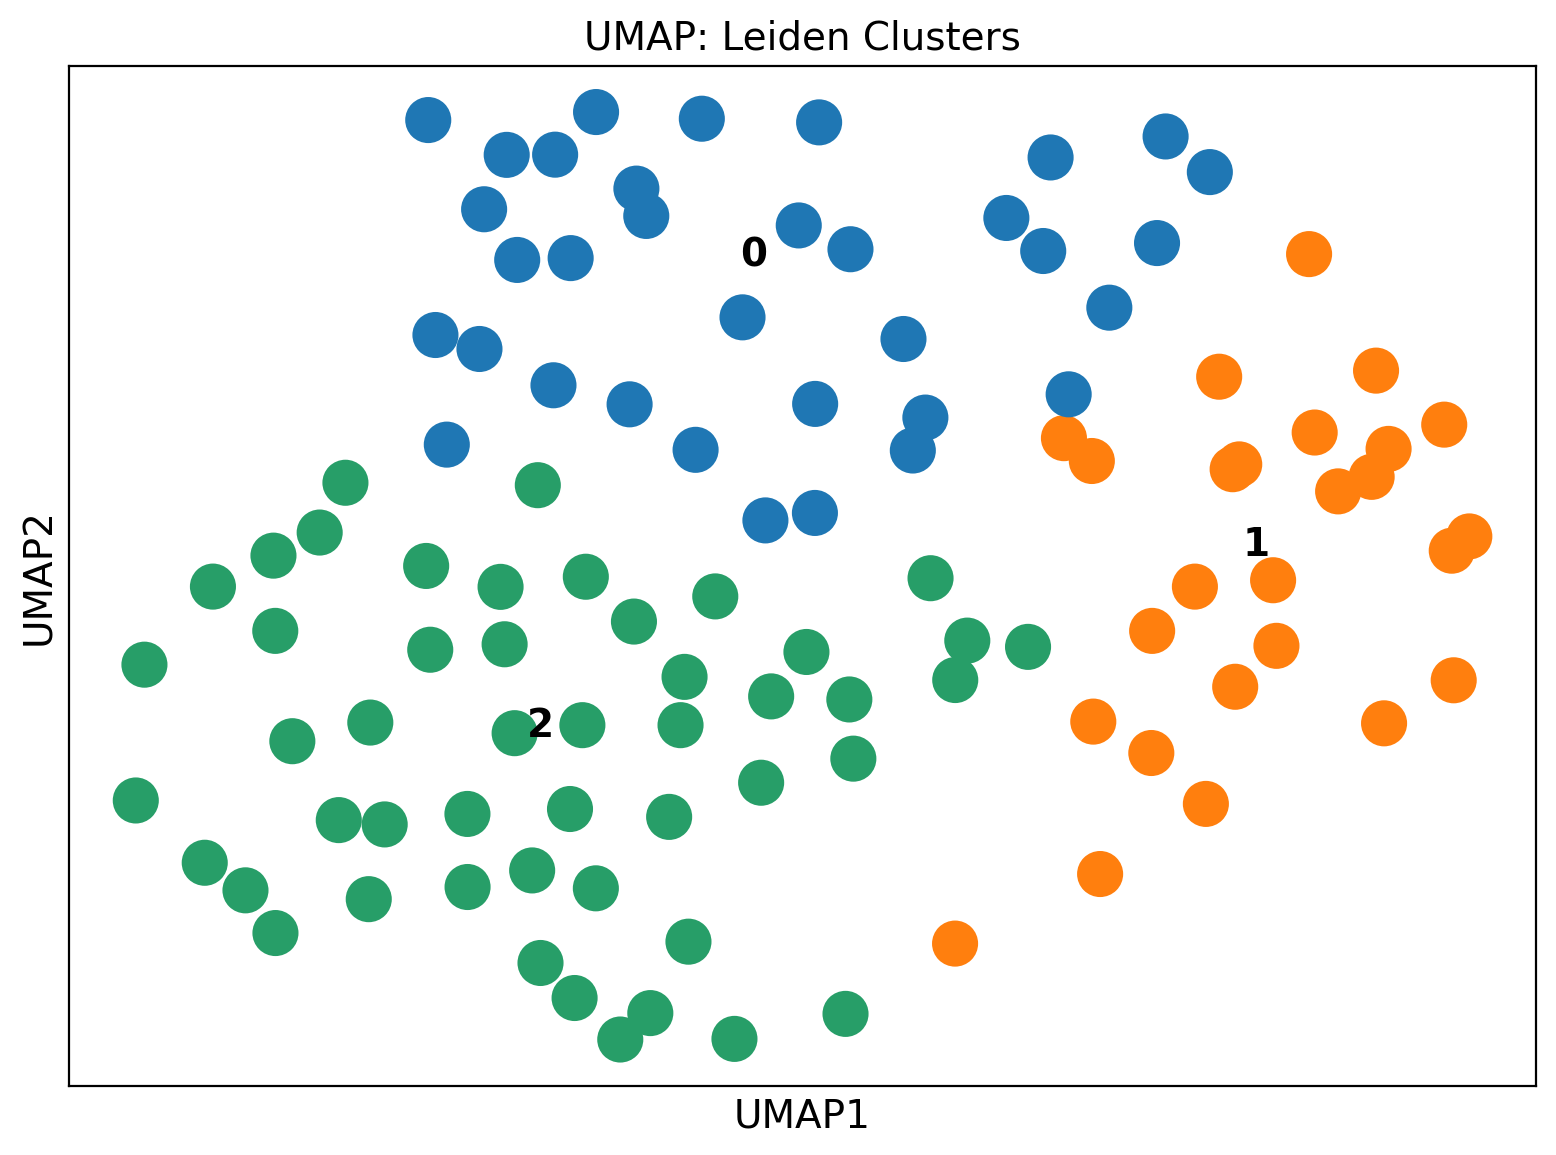


Clusters: 0, 1, 2


In [49]:
# Plot UMAP colored by Leiden clusters
fig, ax = plt.subplots(figsize=(8, 6))
sc.pl.umap(adata, color='leiden', legend_loc='on data', title='UMAP: Leiden Clusters', ax=ax, show=False)
plt.tight_layout()
plt.show()

print(f"\nClusters: {', '.join(sorted(adata.obs['leiden'].unique()))}")

## Cell Type Annotation

In [41]:
# Prepare gene symbols for CellTypist (map Ensembl IDs to symbols and aggregate)
import os
import pandas as pd
import numpy as np
import scipy.sparse as sp
import anndata as ad
import scanpy as sc

print("Preparing gene symbols for CellTypist...")

t2g_path = 'data/simpleaf_index/index/t2g_3col.tsv'
adata_ct = None

if os.path.exists(t2g_path):
    df = pd.read_csv(t2g_path, sep='\t', header=None)
    if df.shape[1] >= 3:
        df.columns = ['transcript_id', 'gene_id', 'gene_name']
    elif df.shape[1] == 2:
        df.columns = ['transcript_id', 'gene_id']
        df['gene_name'] = pd.NA
    else:
        raise RuntimeError(f"Unexpected columns in {t2g_path}: {df.shape[1]}")

    # Build mapping from gene_id (with/without version) to gene_name; fall back to gene_id when name is missing
    df['gene_id_base'] = df['gene_id'].astype(str).str.split('.').str[0]
    gid2name_raw = dict(zip(df['gene_id_base'].astype(str), df['gene_name']))

    def map_to_symbol(gid_base: str) -> str:
        name = gid2name_raw.get(gid_base, None)
        if name is not None and not (pd.isna(name) or (isinstance(name, str) and name.strip().lower() == 'nan') or name == ''):
            return str(name)
        return gid_base

    # Clean current feature names and map to symbols
    current = np.array([str(x) for x in adata.var_names])
    base = np.array([s.rsplit('-', 1)[0] for s in current])  # remove possible -S/-U/-A suffix only
    base2 = np.array([b.split('.')[0] for b in base])

    symbols = np.array([map_to_symbol(b) for b in base2], dtype=object)

    # Aggregate duplicate symbols by summing columns
    uniq, inv = np.unique(symbols, return_inverse=True)
    M = sp.csr_matrix((np.ones(len(inv), dtype=np.int8), (np.arange(len(inv)), inv)), shape=(len(inv), len(uniq)))
    Xc = adata.X @ M

    adata_ct = ad.AnnData(Xc, obs=adata.obs.copy())
    adata_ct.var_names = uniq

    # Ensure the matrix matches CellTypist expectation: log1p-normalized to 1e4 per cell
    sc.pp.normalize_total(adata_ct, target_sum=1e4)
    sc.pp.log1p(adata_ct)

    print(f"Constructed CellTypist view: {adata_ct.n_obs} cells x {adata_ct.n_vars} gene symbols")
else:
    print(f"Mapping file not found: {t2g_path}. Proceeding without gene symbol conversion.")


Preparing gene symbols for CellTypist...
normalizing counts per cell
    finished (0:00:00)
Constructed CellTypist view: 109 cells x 1 gene symbols
    finished (0:00:00)
Constructed CellTypist view: 109 cells x 1 gene symbols


In [ ]:
import celltypist
from celltypist import models

# Choose input: prefer gene-symbol aggregated view for CellTypist if available
adata_for_ct = adata_ct if 'adata_ct' in globals() and adata_ct is not None else adata

# Download model (Immune_All_High for immune cells)
print("Downloading CellTypist model (Immune_All_High)...")
models.download_models(model='Immune_All_High.pkl', force_update=False)

# Load model
print("Loading model...")
model = models.Model.load(model='Immune_All_High.pkl')

# Predict cell types with graceful fallback if no gene overlap
print("Predicting cell types...")
try:
    predictions = celltypist.annotate(adata_for_ct, model='Immune_All_High.pkl', majority_voting=True)
    # Add predictions to analysis AnnData (used for UMAP)
    adata.obs['cell_type'] = predictions.predicted_labels.majority_voting
    adata.obs['cell_type_raw'] = predictions.predicted_labels.predicted_labels
    print(f"\nCell type annotation complete")
    print(f"  Identified {adata.obs['cell_type'].nunique()} cell types:")
    for ct in sorted(adata.obs['cell_type'].unique()):
        count = (adata.obs['cell_type'] == ct).sum()
        print(f"    {ct}: {count} cells")
except ValueError as e:
    print(f"CellTypist failed due to feature mismatch: {e}")
    print("Assigning 'Unknown' to all cells for deliverable completeness.")
    adata.obs['cell_type'] = 'Unknown'
    adata.obs['cell_type_raw'] = 'Unknown'


📂 Storing models in /home/ryan/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)


Loading model...
Predicting cell types...


FileNotFoundError: 🛑 No such file: Healthy_Lung.pkl

## Cell Type Visualization

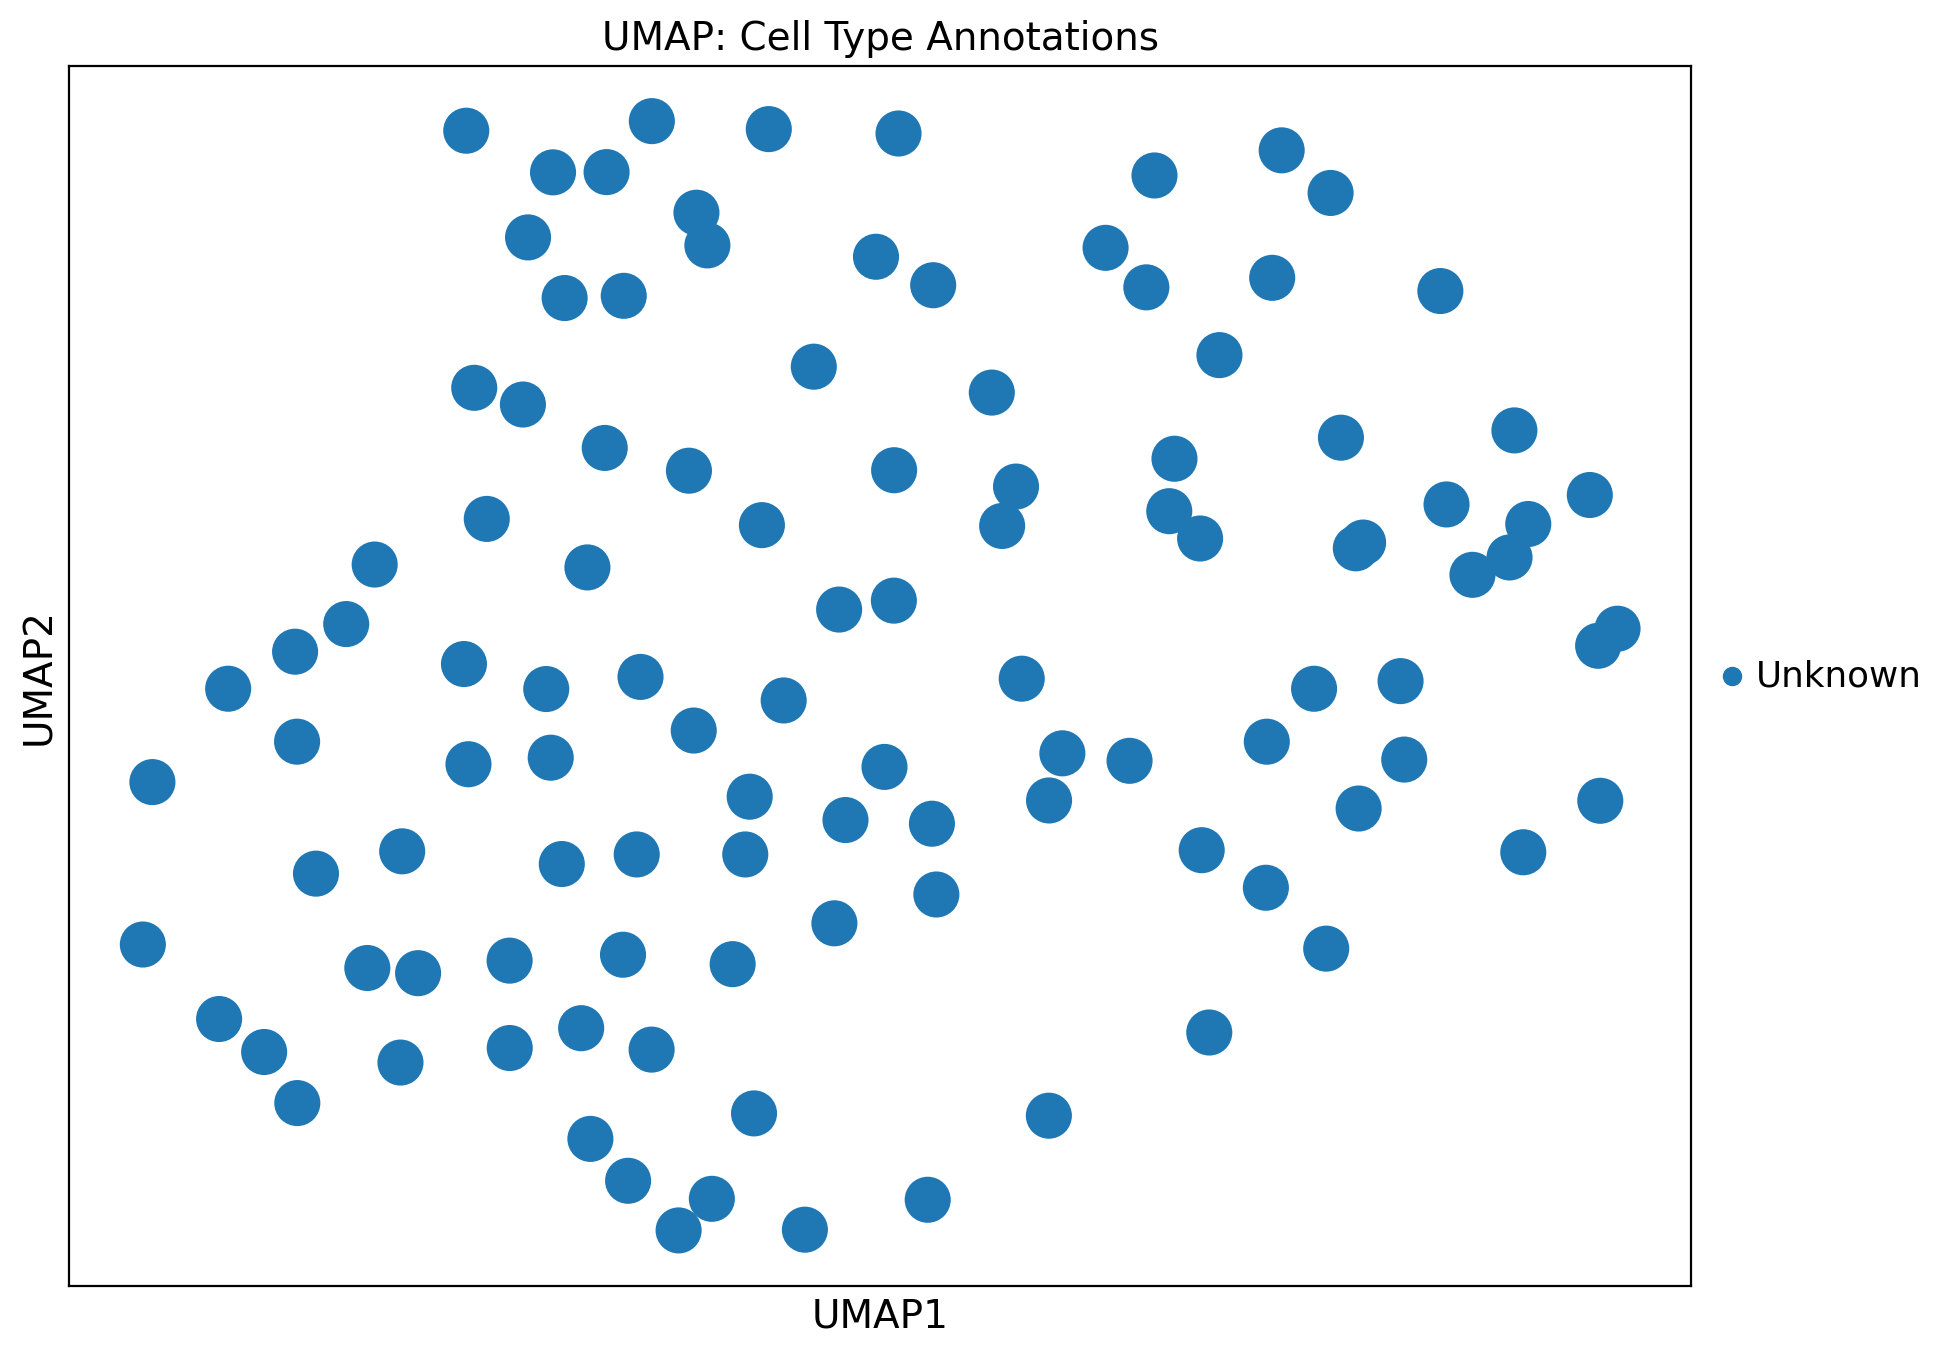


ANALYSIS COMPLETE
AnnData matrix: 109 cells x 19 genes
Leiden clustering: 3 clusters
CellTypist annotation: 1 cell types


In [48]:
# Plot UMAP colored by cell types
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(adata, color='cell_type', title='UMAP: Cell Type Annotations', ax=ax, show=False)
plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"AnnData matrix: {adata.n_obs} cells x {adata.n_vars} genes")
print(f"Leiden clustering: {adata.obs['leiden'].nunique()} clusters")
print(f"CellTypist annotation: {adata.obs['cell_type'].nunique()} cell types")
print("="*60)